# DepMap Mutation 기반 유전체 불안정성(WGD/CIN/LOH) 예측 — 전체 파이프라인

DepMap Public 26Q1 / 1,631개 세포주 / hotspot 554 + damaging 19,578 mutation feature 로
Whole Genome Doubling(WGD), Chromosomal Instability(CIN), Loss of Heterozygosity(LOH)를
예측하고, 최소 mutation biomarker panel을 찾는 프로젝트의 전체 파이프라인이다.

전체 코드/문서: https://github.com/lkeonwoo94/AI-bio-proj-team-1

**노트북 구성**
1. 데이터 로드 & 코호트 요약
2. EDA — mutation/표현형 분포
3. 5개 모델 비교 (Logistic/Elastic Net/Random Forest/XGBoost/CatBoost)
4. 최고 성능 모델(Random Forest) confusion matrix
5. 반복 feature selection — 어떤 mutation이 중요한가
6. 최소 mutation panel — 몇 개까지 줄여도 되는가
7. Lineage(암종) 일반화 — GroupKFold / Leave-One-Lineage-Out
8. CIN/LOH 이진화가 정보를 버리는가 — 회귀로 직접 검증
9. Pathway 단위 재집계 (실행 결과 — 음성)
10. Mutation signature(96-class) 표현 (실행 결과 — 양성)
11. 유전자 + Signature 결합 패널
12. Sensitivity/Specificity 트레이드오프
13. TCGA 외부 코호트 검증
14. 최종 후보 Biomarker Panel
15. 결론 및 한계

**중요**: 이 노트북은 무거운 nested cross-validation(모델 5개 × 표현형 3개 × outer
5-fold × inner 5-fold, 실제로는 수십 분\~수 시간 소요)을 노트북 실행마다 새로
돌리지 않는다. 그 계산은 `scripts/`의 개별 스크립트가 이미 수행해 `results/tables/`,
`results/figures/`에 저장해 두었고(모두 git에 커밋됨), 이 노트북은 **그 결과를
불러와 재현·시각화**한다. 각 절에 재현용 스크립트 커맨드를 적어두었다 — 직접
처음부터 다시 돌리고 싶다면 그 커맨드를 실행하면 된다(모든 계산은 §13
원칙에 따라 outer test 데이터가 threshold/feature selection 어디에도 관여하지
않도록 leakage를 방지한다).

In [1]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = REPO_ROOT / "results" / "tables"
FIGURES = REPO_ROOT / "results" / "figures"
INTERIM = REPO_ROOT / "data" / "interim"

# --- 이 노트북은 저장소 코드(src/, scripts/)를 import 하지 않고 단독 실행된다. ---
# src/viz/style.py 의 색·스타일 설정을 그대로 옮겨 둔다.
PHENOTYPE_COLORS = {"wgd": "#c0504d", "cin": "#4f81bd", "loh": "#9bbb59"}
TARGET_LABEL = {"wgd": "WGD", "cin": "CIN", "loh": "LOH"}
TARGETS = ("wgd", "cin", "loh")
NEUTRAL = "#7f7f7f"

_KOREAN_FONTS = ("NanumGothic", "NanumBarunGothic", "NanumSquare",
                 "Noto Sans CJK KR", "Malgun Gothic")


def use_style() -> None:
    """한글 폰트 + 공통 rcParams (src/viz/style.py 와 동일, Agg 백엔드 설정만 제외)."""
    available = {f.name for f in fm.fontManager.ttflist}
    for name in _KOREAN_FONTS:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams.update({
        "axes.unicode_minus": False,   # 한글 폰트에서 마이너스 기호가 깨지는 것 방지
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",
        "font.size": 10,
        "axes.titlesize": 11,
        "legend.frameon": False,
    })


use_style()
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /home/kali/adni-shared/AI-bio-proj-team-1


**Figure 1.** 연구 전체 흐름 — Mutation → WGD/CIN/LOH → Feature selection → Minimal panel.

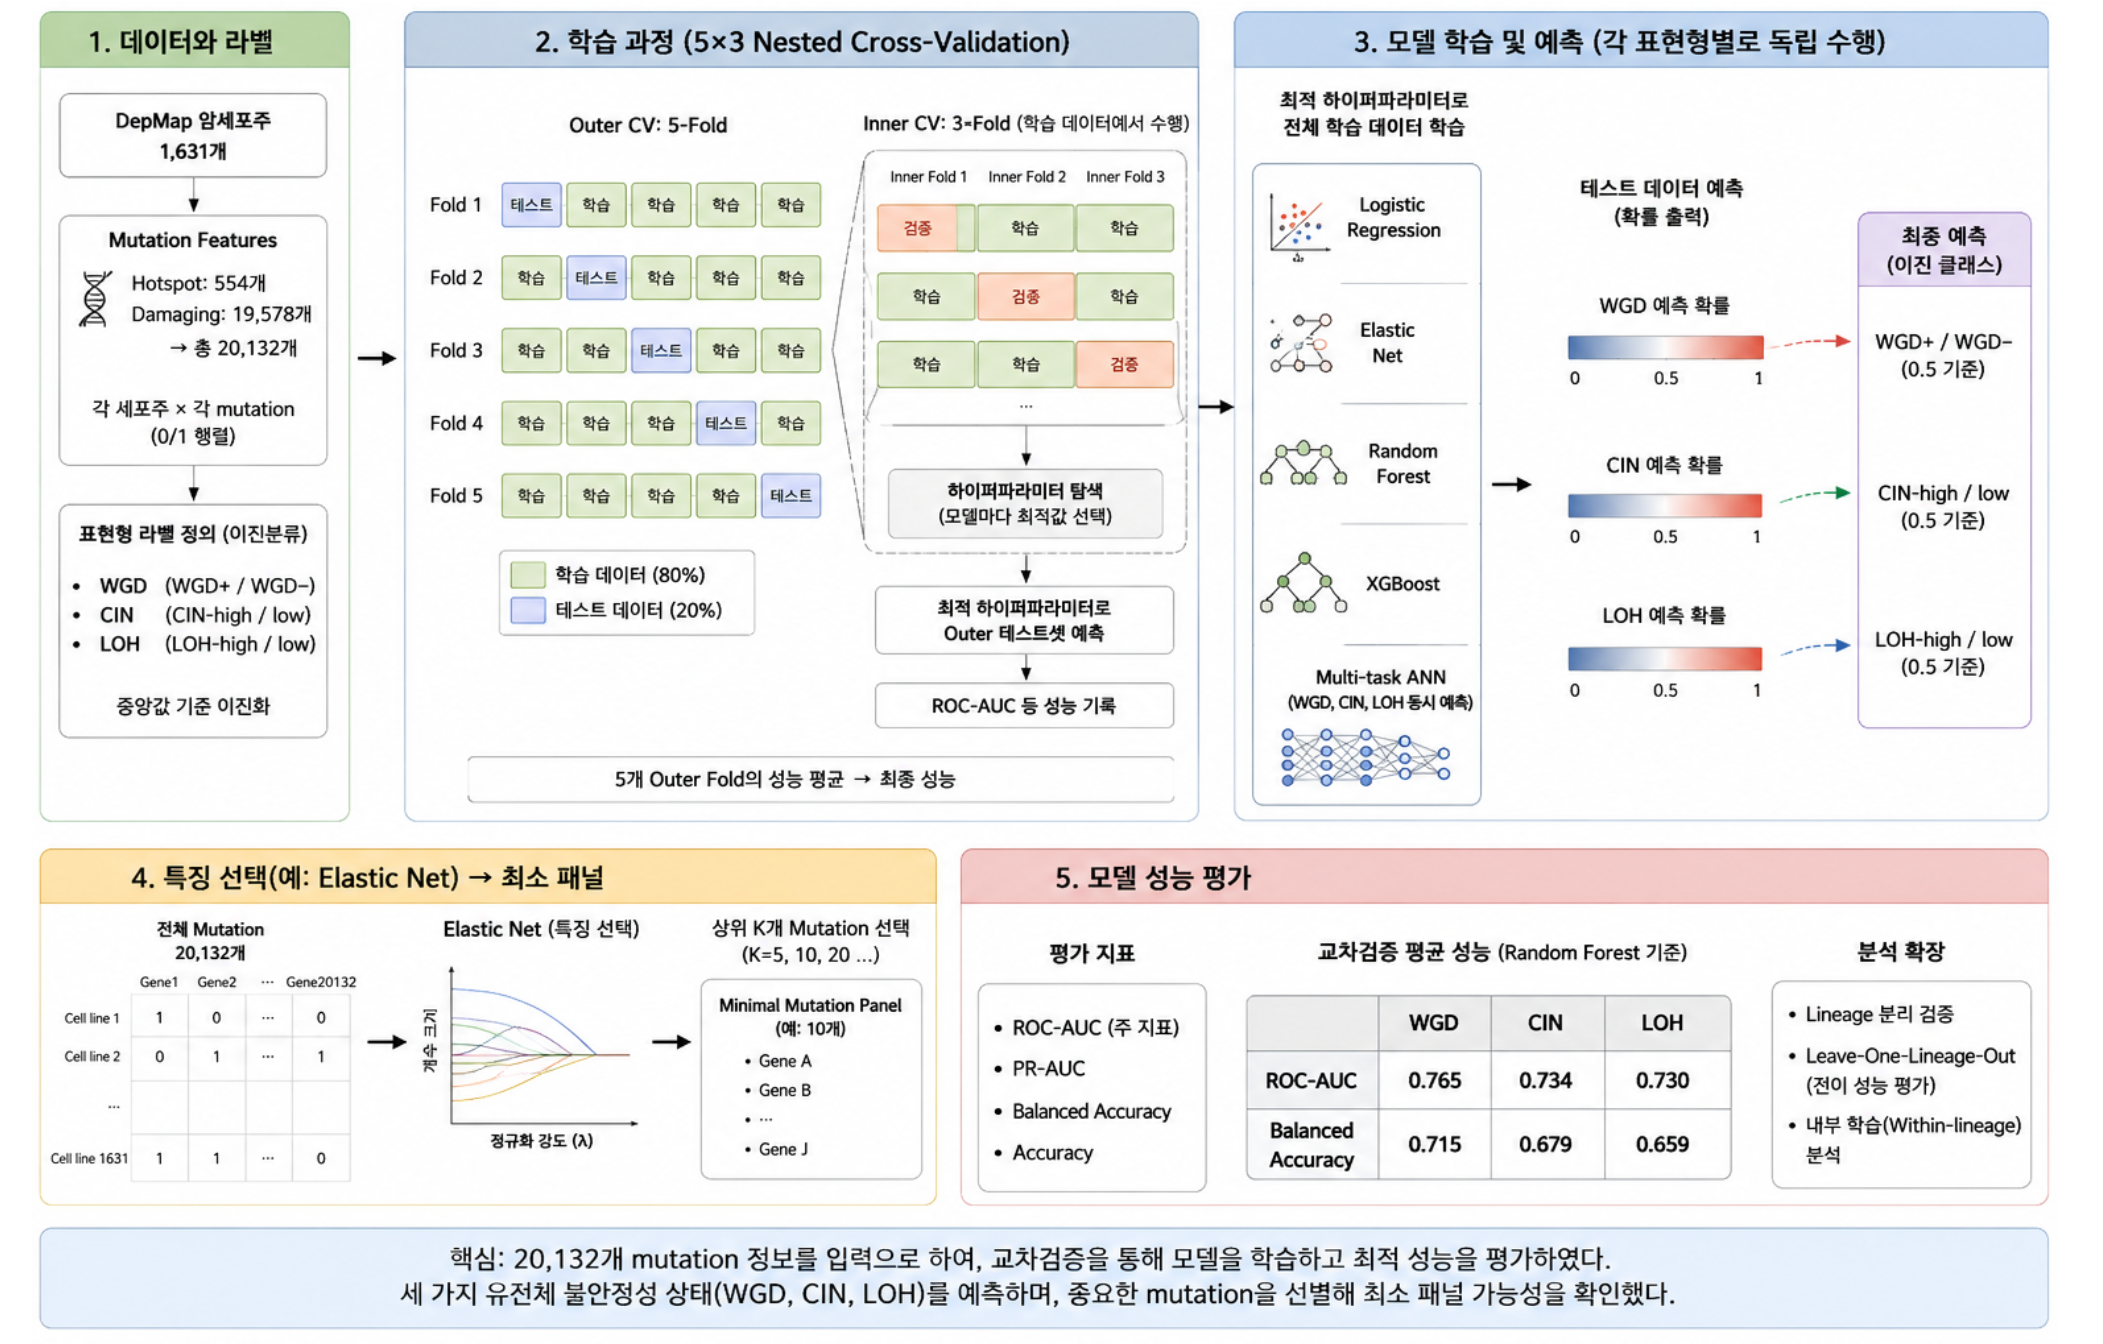

In [2]:
display(Image(filename=str(FIGURES / "fig1_overview.png")))

## 1. 데이터 로드 & 코호트 요약

DepMap 4개 원본 파일(hotspot/damaging mutation matrix, global signatures, model
metadata)을 ModelID 교집합으로 합치고 라벨 결측을 제거한다. 이 단계는 실제로
가볍게 실행된다(수 초).

In [3]:
# src/data/merge.py 의 load_cohort() 가 만들어 둔 캐시를 pandas 로 직접 읽는다.
# 캐시가 없으면 저장소 루트에서 `python scripts/02_qc_merge.py` 를 한 번 실행하면 생긴다.
cohort_X = pd.read_parquet(INTERIM / "cohort_X.parquet")
cohort_y = pd.read_parquet(INTERIM / "cohort_y.parquet")
cohort_groups = pd.read_parquet(INTERIM / "cohort_groups.parquet")["lineage"].fillna("Unknown")

n_hot = int(cohort_X.columns.str.endswith("_hotspot").sum())
n_dam = cohort_X.shape[1] - n_hot
print(f"세포주 {len(cohort_X):,}개 | feature {cohort_X.shape[1]:,}개 "
      f"(hotspot {n_hot:,} / damaging {n_dam:,}) | lineage {cohort_groups.nunique()}종")
print()
print("X shape:", cohort_X.shape, "| dtype:", cohort_X.dtypes.iloc[0])
print("y columns:", list(cohort_y.columns))
print("lineage 수:", cohort_groups.nunique())
cohort_y.describe()

세포주 1,631개 | feature 20,132개 (hotspot 554 / damaging 19,578) | lineage 32종

X shape: (1631, 20132) | dtype: int8
y columns: ['wgd', 'cin', 'loh']
lineage 수: 32


,wgd,cin,loh
count,1631.000000,1631.000000,1631.000000
mean,0.652361,0.460105,0.210227
std,0.476367,0.246927,0.162156
min,0.000000,0.000000,0.000000
25%,0.000000,0.242061,0.073253
50%,1.000000,0.533116,0.187137
75%,1.000000,0.663973,0.318579
max,1.000000,0.859347,0.929901


데이터 원본 파일별 상세 통계는 `docs/depmap/input_data_summary.md`,
mutation matrix 병합 과정은 `docs/depmap/mutation_matrix.md`,
라벨(WGD/CIN/LoHFraction) 정의는 `docs/depmap/global_signatures.md` 참고.

## 2. EDA — mutation 빈도 / 표현형 분포

**Figure 2.** WGD/CIN/LOH 세 표현형의 분포. WGD는 이진(65.2%가 양성), CIN은
이봉형, LOH는 0 근처로 치우친 분포다.

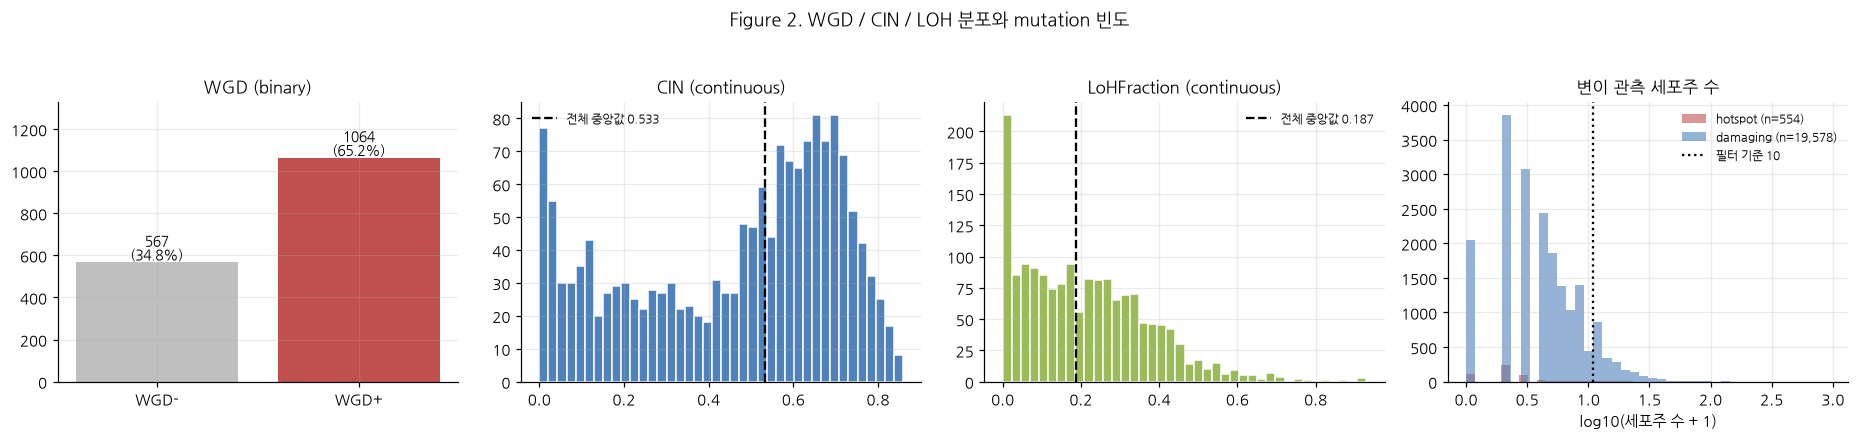

In [4]:
# Figure 2 — scripts/04_eda.py 의 plot_distributions() 를 그대로 옮긴 것.
freq = pd.DataFrame({
    "feature": cohort_X.columns,
    "kind": np.where(cohort_X.columns.str.endswith("_hotspot"), "hotspot", "damaging"),
    "n_cell_lines": (cohort_X > 0).sum(axis=0).to_numpy(),
})

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

counts = cohort_y["wgd"].value_counts().sort_index()
axes[0].bar(["WGD-", "WGD+"], counts.to_numpy(), color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]])
for i, v in enumerate(counts):
    axes[0].text(i, v, f"{v}\n({v / len(cohort_y):.1%})", ha="center", va="bottom", fontsize=9)
axes[0].set_title("WGD (binary)")
axes[0].set_ylim(0, counts.max() * 1.25)

for ax, name, label in ((axes[1], "cin", "CIN"), (axes[2], "loh", "LoHFraction")):
    ax.hist(cohort_y[name], bins=40, color=PHENOTYPE_COLORS[name], edgecolor="white")
    med = cohort_y[name].median()
    ax.axvline(med, color="k", ls="--", lw=1.5, label=f"전체 중앙값 {med:.3f}")
    ax.set_title(f"{label} (continuous)")
    ax.legend(fontsize=8)

for kind, color in (("hotspot", "#c0504d"), ("damaging", "#4f81bd")):
    sub = freq[freq.kind == kind].n_cell_lines
    axes[3].hist(np.log10(sub + 1), bins=40, alpha=0.6, label=f"{kind} (n={len(sub):,})", color=color)
axes[3].axvline(np.log10(11), color="k", ls=":", lw=1.5, label="필터 기준 10")
axes[3].set_title("변이 관측 세포주 수")
axes[3].set_xlabel("log10(세포주 수 + 1)")
axes[3].legend(fontsize=8)

fig.suptitle("Figure 2. WGD / CIN / LOH 분포와 mutation 빈도", y=1.04, fontsize=12)
fig.tight_layout()
plt.show()

## 3. 모델 비교 — 5개 모델 × 3표현형

Logistic Regression, Elastic Net, Random Forest, XGBoost, CatBoost를 동일한
nested cross-validation(outer 5-fold × inner 5-fold) 조건에서 비교했다. 희귀
변이 제거, CIN/LOH 이진화 threshold, hyperparameter, 분류 threshold는 모두 각
training fold 내부에서만 결정된다(outer test 데이터는 관여하지 않음, README §13).

재현: `python scripts/05_run_cv.py --model {model} --target {target}`
(model × target 조합마다), 집계는 `python scripts/06_compare_models.py`.

In [5]:
day10 = pd.read_csv(TABLES / "day10_model_comparison.csv")
day10_pivot = day10.pivot(index="model", columns="target", values="roc_auc")
day10_pivot = day10_pivot[["wgd", "cin", "loh"]].sort_values("wgd", ascending=False)
print("모델별 ROC-AUC (random 5-fold)")
day10_pivot.round(3)

모델별 ROC-AUC (random 5-fold)


target,wgd,cin,loh
model,,,
random_forest,0.765,0.734,0.730
catboost,0.762,0.711,0.717
xgboost,0.757,0.729,0.728
elastic_net,0.749,0.681,0.711
logistic,0.723,0.672,0.683
multitask_ann,0.704,0.671,0.667


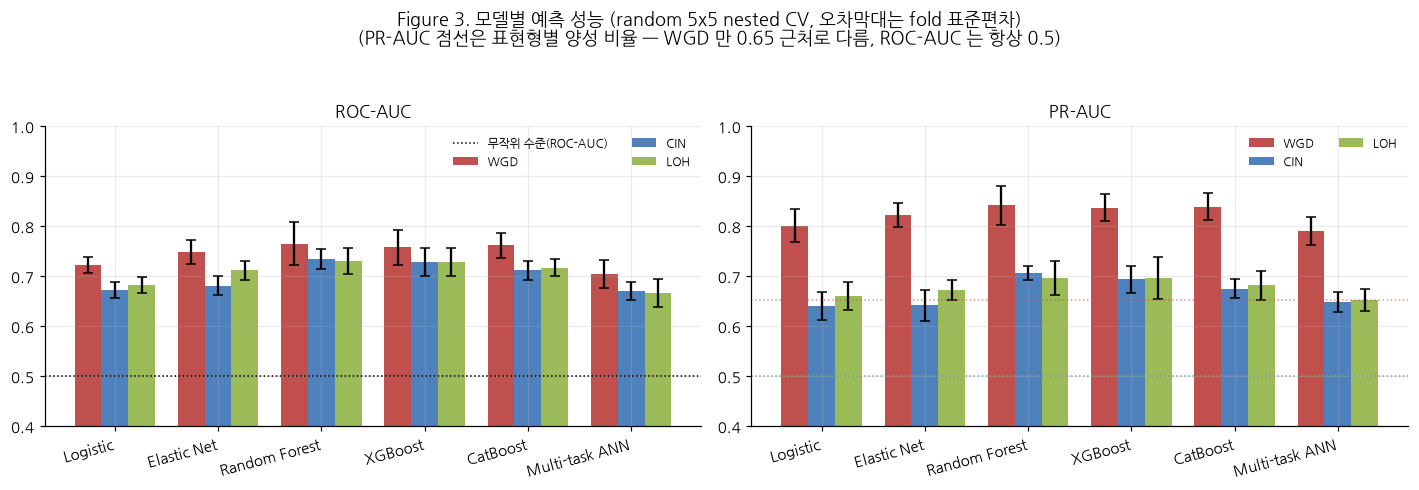

In [6]:
# Figure 3 — scripts/06_compare_models.py 의 plot_comparison() 을 그대로 옮긴 것.
MODEL_ORDER = ["logistic", "elastic_net", "random_forest", "xgboost", "catboost", "multitask_ann"]
MODEL_LABEL = {"logistic": "Logistic", "elastic_net": "Elastic Net",
               "random_forest": "Random Forest", "xgboost": "XGBoost",
               "catboost": "CatBoost", "multitask_ann": "Multi-task ANN"}

# cv_random_{model}_{target}.csv 만 정확히 읽는다 — glob 으로 긁으면
# cv_random_random_forest_damaging_only_wgd.csv(보조 파일)까지 섞여 WGD/RF 행이 오염된다.
frames = [pd.read_csv(TABLES / f"cv_random_{m}_{t}.csv")
          for m in MODEL_ORDER for t in TARGETS
          if (TABLES / f"cv_random_{m}_{t}.csv").exists()]
cv = pd.concat(frames, ignore_index=True)

# PR-AUC 의 무작위 기준선은 0.5 가 아니라 표현형별 양성 비율이다.
prevalence = {"wgd": float(cohort_y.wgd.mean())}
for t in ("cin", "loh"):
    prevalence[t] = float((cohort_y[t] >= cohort_y[t].median()).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
models = [m for m in MODEL_ORDER if m in set(cv.model)]
width, x = 0.26, np.arange(len(models))

for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for i, target in enumerate(TARGETS):
        sub = cv[cv.target == target]
        means = [sub[sub.model == m][metric].mean() for m in models]
        errs = [sub[sub.model == m][metric].std() for m in models]
        ax.bar(x + (i - 1) * width, means, width, yerr=errs, capsize=3,
               label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
    if metric == "roc_auc":
        ax.axhline(0.5, color="k", ls=":", lw=1, label="무작위 수준(ROC-AUC)")
    else:
        for target in TARGETS:
            ax.axhline(prevalence[target], color=PHENOTYPE_COLORS[target], ls=":", lw=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABEL[m] for m in models], rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle("Figure 3. 모델별 예측 성능 (random 5x5 nested CV, 오차막대는 fold 표준편차)\n"
             "(PR-AUC 점선은 표현형별 양성 비율 — WGD 만 0.65 근처로 다름, ROC-AUC 는 항상 0.5)",
             y=1.05, fontsize=12)
fig.tight_layout()
plt.show()

**Random Forest가 세 표현형 모두에서 1위**다(WGD 0.765 / CIN 0.734 / LOH 0.730).
비선형 모델(RF/XGBoost/CatBoost, 평균 0.73\~0.74)이 선형 모델(평균 0.69\~0.71)을
일관되게 앞서지만 그 차이는 0.05 내외다.

## 4. Random Forest confusion matrix (최고 성능 모델)

5개 outer fold의 test 예측을 모두 모아(pooled) 하나의 confusion matrix로
합쳤다. Threshold는 각 fold의 training 데이터 안에서 out-of-fold 예측으로만
결정했다(§13).

재현: `python scripts/33_rf_confusion_matrix.py`, `python scripts/34_plot_rf_confusion_matrix.py`.

In [7]:
cm = pd.read_csv(TABLES / "day33_rf_confusion_matrix.csv")
cm

,target,tn,fp,fn,tp,n,sensitivity,specificity,balanced_accuracy
0,wgd,384,183,264,800,1631,0.751880,0.677249,0.714564
1,cin,538,277,248,568,1631,0.696078,0.660123,0.678101
2,loh,494,321,207,609,1631,0.746324,0.606135,0.676229


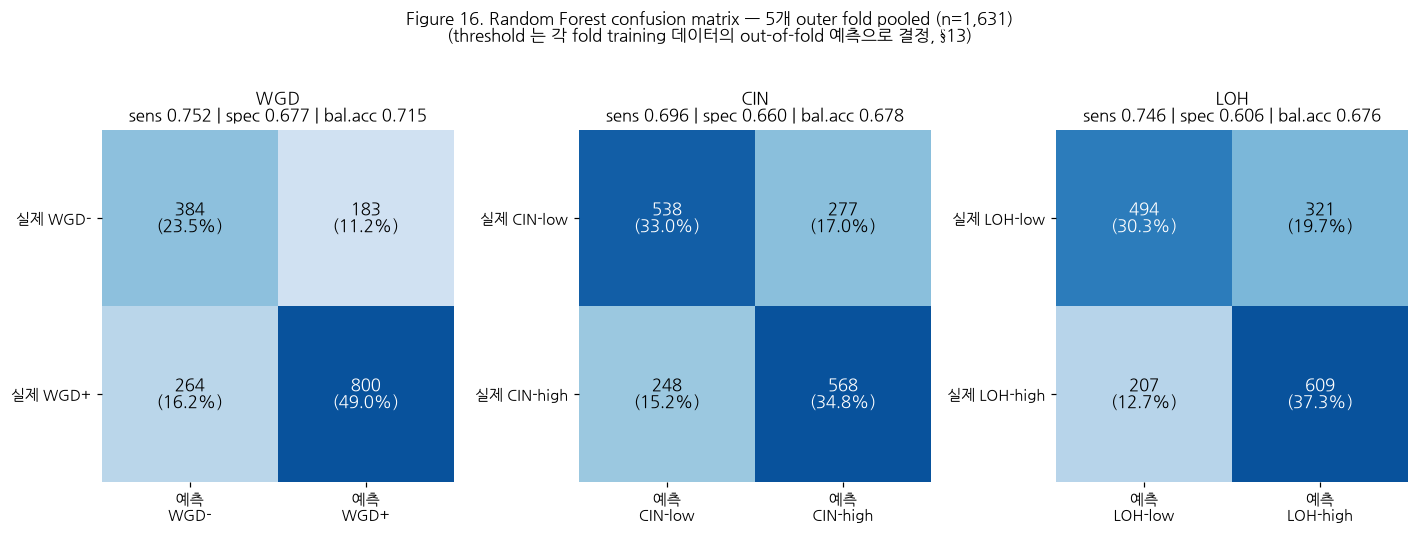

In [8]:
# Figure 16 — scripts/34_plot_rf_confusion_matrix.py 를 그대로 옮긴 것.
CLASS_LABEL = {"wgd": ("WGD-", "WGD+"), "cin": ("CIN-low", "CIN-high"),
               "loh": ("LOH-low", "LOH-high")}
cm_df = pd.read_csv(TABLES / "day33_rf_confusion_matrix.csv").set_index("target")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, target in zip(axes, TARGETS):
    row = cm_df.loc[target]
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    cm_pct = cm / cm.sum() * 100
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=cm_pct.max() * 1.15)
    labels = CLASS_LABEL[target]
    for i in range(2):
        for j in range(2):
            color = "white" if cm_pct[i, j] > cm_pct.max() * 0.6 else "black"
            ax.text(j, i, f"{int(cm[i, j])}\n({cm_pct[i, j]:.1f}%)",
                    ha="center", va="center", fontsize=11, color=color)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"예측\n{labels[0]}", f"예측\n{labels[1]}"])
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"실제 {labels[0]}", f"실제 {labels[1]}"])
    ax.set_title(f"{TARGET_LABEL[target]}\nsens {row.sensitivity:.3f} | "
                 f"spec {row.specificity:.3f} | bal.acc {row.balanced_accuracy:.3f}")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

fig.suptitle("Figure 16. Random Forest confusion matrix — 5개 outer fold pooled (n=1,631)\n"
             "(threshold 는 각 fold training 데이터의 out-of-fold 예측으로 결정, §13)",
             y=1.06, fontsize=11)
fig.tight_layout()
plt.show()

## 5. 반복 Feature Selection — 어떤 mutation이 중요한가

각 outer fold의 training data에서 feature selection을 반복해, 5개 fold 모두에서
선택된("전 fold 공통") 유전자를 찾는다. Elastic Net과 Random Forest 두 모델
기준으로 각각 뽑았다.

재현: `python scripts/07_aggregate_selection.py --model {elastic_net,random_forest}`.

In [9]:
for model in ("elastic_net", "random_forest"):
    print(f"=== {model} ===")
    for target in ("wgd", "cin", "loh"):
        df = pd.read_csv(TABLES / f"day11_selection_{model}_{target}.csv")
        common = df[df.selection_freq == 1.0]
        genes = ", ".join(common.gene.head(8))
        print(f"  {target.upper()}: 전 fold(5/5) 공통 {len(common)}개 — {genes}")
    print()

=== elastic_net ===
  WGD: 전 fold(5/5) 공통 12개 — TP53, BRAF, ID3, TERT, TP53, CREBBP, LRP1B, CCND3
  CIN: 전 fold(5/5) 공통 5개 — TP53, ID3, BRAF, TERT, RB1
  LOH: 전 fold(5/5) 공통 9개 — TP53, NF2, ID3, PITX1, RB1, BRAF, CREBBP, MUC19

=== random_forest ===
  WGD: 전 fold(5/5) 공통 19개 — TP53, TP53, TERT, BRAF, ID3, LRP1B, TTN, KRAS
  CIN: 전 fold(5/5) 공통 21개 — TP53, TP53, TERT, RB1, ID3, BRAF, PIK3CA, KRAS
  LOH: 전 fold(5/5) 공통 18개 — TP53, TP53, RB1, ID3, KRAS, NF2, ARID1A, PITX1



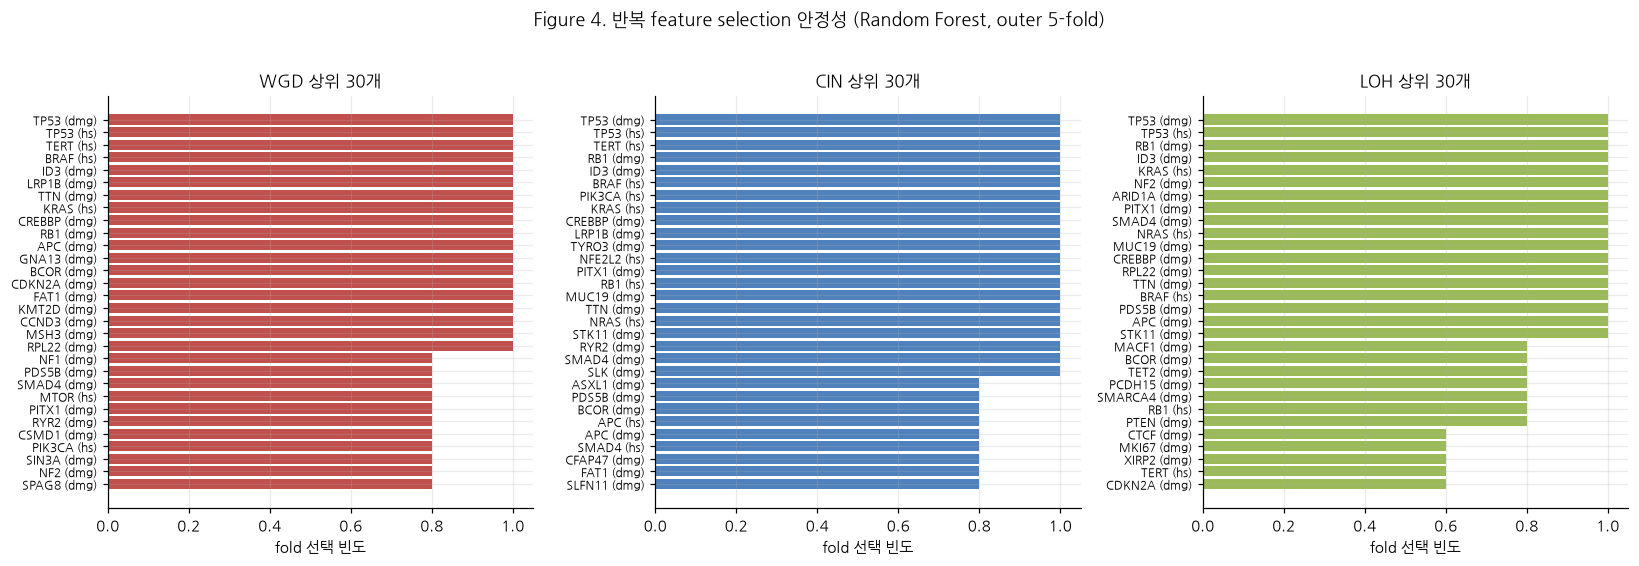

In [10]:
# Figure 4 — scripts/07_aggregate_selection.py 의 plot_stability() 를 그대로 옮긴 것.
# day11_selection_*.csv 가 이미 fold 집계 결과(selection_freq 포함)다.
TOP_N = 30


def short(feature: str, width: int = 22) -> str:
    """'TP53 (7157)_damaging' -> 'TP53 (dmg)'"""
    gene = feature.split(" (")[0]
    kind = "hs" if feature.endswith("_hotspot") else "dmg"
    return f"{gene} ({kind})"[:width]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, target in zip(axes, TARGETS):
    agg = pd.read_csv(TABLES / f"day11_selection_random_forest_{target}.csv")
    top = agg.head(TOP_N).iloc[::-1]
    ax.barh([short(f) for f in top.feature], top.selection_freq, color=PHENOTYPE_COLORS[target])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("fold 선택 빈도")
    ax.set_title(f"{TARGET_LABEL[target]} 상위 {TOP_N}개")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Figure 4. 반복 feature selection 안정성 (Random Forest, outer 5-fold)",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## 6. 최소 mutation panel — 몇 개까지 줄여도 되는가

5/10/20/50개로 축소한 패널이 전체 feature 대비 성능을 얼마나 유지하는지,
그리고 fold 간 패널 구성의 안정성(Jaccard 유사도)을 본다.

재현: `python scripts/08_panel_curve.py --model {elastic_net,random_forest}`.

In [11]:
panel = pd.read_csv(TABLES / "day12_panel_metrics_random_forest.csv")
panel_pivot = panel.pivot_table(index="target", columns="panel_size", values="roc_auc", aggfunc="mean")
panel_pivot = panel_pivot.reindex(columns=["5", "10", "20", "50", "all"])
print("Random Forest — 패널 크기별 ROC-AUC")
panel_pivot.round(3)

Random Forest — 패널 크기별 ROC-AUC


panel_size,5,10,20,50,all
target,,,,,
cin,0.671,0.682,0.699,0.718,0.734
loh,0.666,0.687,0.709,0.715,0.730
wgd,0.723,0.729,0.740,0.751,0.765


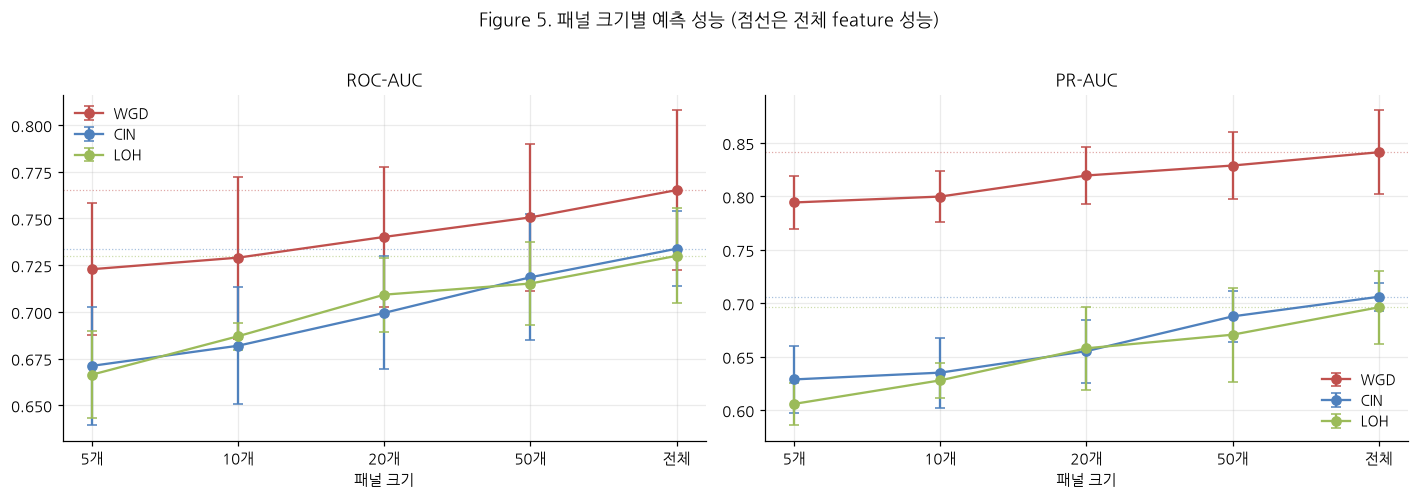

In [12]:
# Figure 5 — scripts/08_panel_curve.py 의 plot_curve() 를 그대로 옮긴 것.
metrics = pd.read_csv(TABLES / "day12_panel_metrics_random_forest.csv")
metrics["panel_size"] = metrics["panel_size"].astype(str)
sizes = sorted({int(s) for s in metrics.panel_size.unique() if s != "all"})
order = [str(s) for s in sizes] + ["all"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for target in TARGETS:
        sub = metrics[metrics.target == target]
        g = sub.groupby("panel_size")[metric]
        mean, std = g.mean().reindex(order), g.std().reindex(order)
        ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                    label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
        full = mean.get("all")
        if pd.notna(full):
            ax.axhline(full, color=PHENOTYPE_COLORS[target], ls=":", lw=0.8, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}개" if o != "all" else "전체" for o in order])
    ax.set_xlabel("패널 크기")
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle("Figure 5. 패널 크기별 예측 성능 (점선은 전체 feature 성능)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

**10개 패널로 전체 성능의 93\~99%가 유지된다.** 다만 fold마다 어떤 유전자가
뽑히는지는 달라진다(Jaccard 유사도 <1) — `day12_panel_stability_random_forest.csv`
참고. 자세한 해석은 `docs/research/2026-08-16/final_conclusion.md` §26④,
"Day 11/12 Random Forest 재검증" 절 참고.

## 7. Lineage(암종) 일반화 — GroupKFold / Leave-One-Lineage-Out

같은 lineage(암종)의 세포주가 train/test에 섞이지 않도록 분리하면 성능이
어떻게 달라지는지 본다.

재현: `python scripts/09_lineage_validation.py --model {elastic_net,random_forest}`,
`python scripts/11_lineage_specific.py`,
`python scripts/15_lineage_hypothesis_test.py`.

In [13]:
lineage_cmp = pd.read_csv(TABLES / "day13_lineage_comparison_random_forest.csv")
lineage_cmp

,target,group,random,차이
0,cin,0.677864,0.733763,-0.055899
1,loh,0.683452,0.729966,-0.046514
2,wgd,0.700460,0.765161,-0.064701


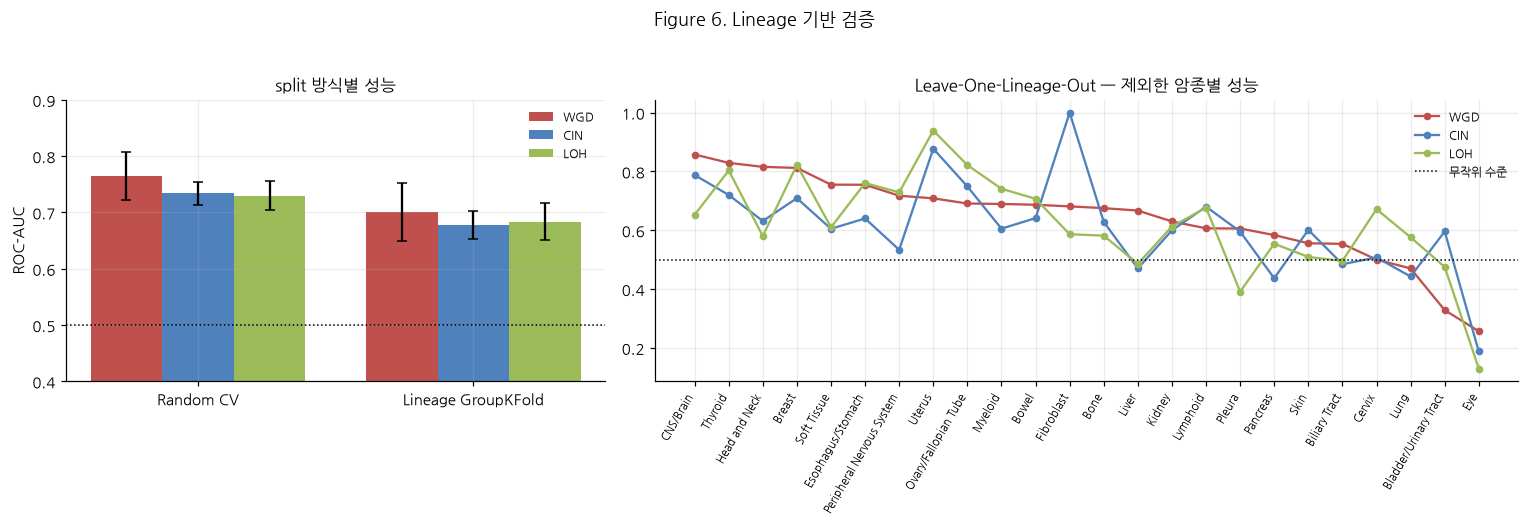

In [14]:
# Figure 6 — scripts/09_lineage_validation.py 의 plot_lineage_comparison() 을 그대로 옮긴 것.
rand = pd.concat([pd.read_csv(TABLES / f"cv_random_random_forest_{t}.csv") for t in TARGETS],
                 ignore_index=True)
group = pd.concat([pd.read_csv(TABLES / f"cv_group_random_forest_{t}.csv") for t in TARGETS],
                  ignore_index=True)
lolo = pd.concat([pd.read_csv(TABLES / f"cv_lolo_random_forest_{t}.csv") for t in TARGETS],
                 ignore_index=True)
combined = pd.concat([rand, group], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.6]})
schemes = ["random", "group"]
width, x = 0.26, np.arange(len(schemes))
for i, target in enumerate(TARGETS):
    means = [combined[(combined.target == target) & (combined.scheme == s)].roc_auc.mean() for s in schemes]
    errs = [combined[(combined.target == target) & (combined.scheme == s)].roc_auc.std() for s in schemes]
    axes[0].bar(x + (i - 1) * width, means, width, yerr=errs, capsize=3,
                label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
axes[0].axhline(0.5, color="k", ls=":", lw=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Random CV", "Lineage GroupKFold"])
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.4, 0.9)
axes[0].set_title("split 방식별 성능")
axes[0].legend(fontsize=8)

order = (lolo[lolo.target == "wgd"].sort_values("roc_auc", ascending=False)
         .held_out_lineage.tolist())
for target in TARGETS:
    sub = lolo[lolo.target == target].set_index("held_out_lineage").reindex(order)
    axes[1].plot(range(len(order)), sub.roc_auc, marker="o", ms=4,
                 label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
axes[1].axhline(0.5, color="k", ls=":", lw=1, label="무작위 수준")
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order, rotation=60, ha="right", fontsize=7)
axes[1].set_title("Leave-One-Lineage-Out — 제외한 암종별 성능")
axes[1].legend(fontsize=8)

fig.suptitle("Figure 6. Lineage 기반 검증", y=1.03, fontsize=12)
fig.tight_layout()
plt.show()

Leave-One-Lineage-Out(LOLO)에서는 암종별 성능 편차가 훨씬 크다(WGD 기준
0.314\~0.882). 왜 어떤 암종에서는 신호가 있고 어떤 암종에서는 없는지 다섯 개
가설(기저율, 표본 크기, TP53 변이율, mutation burden, TP53 변이율의 극단성)로
검정했으나 모두 기각됐다 — 단순 단변량 교란변수로는 설명되지 않는다.

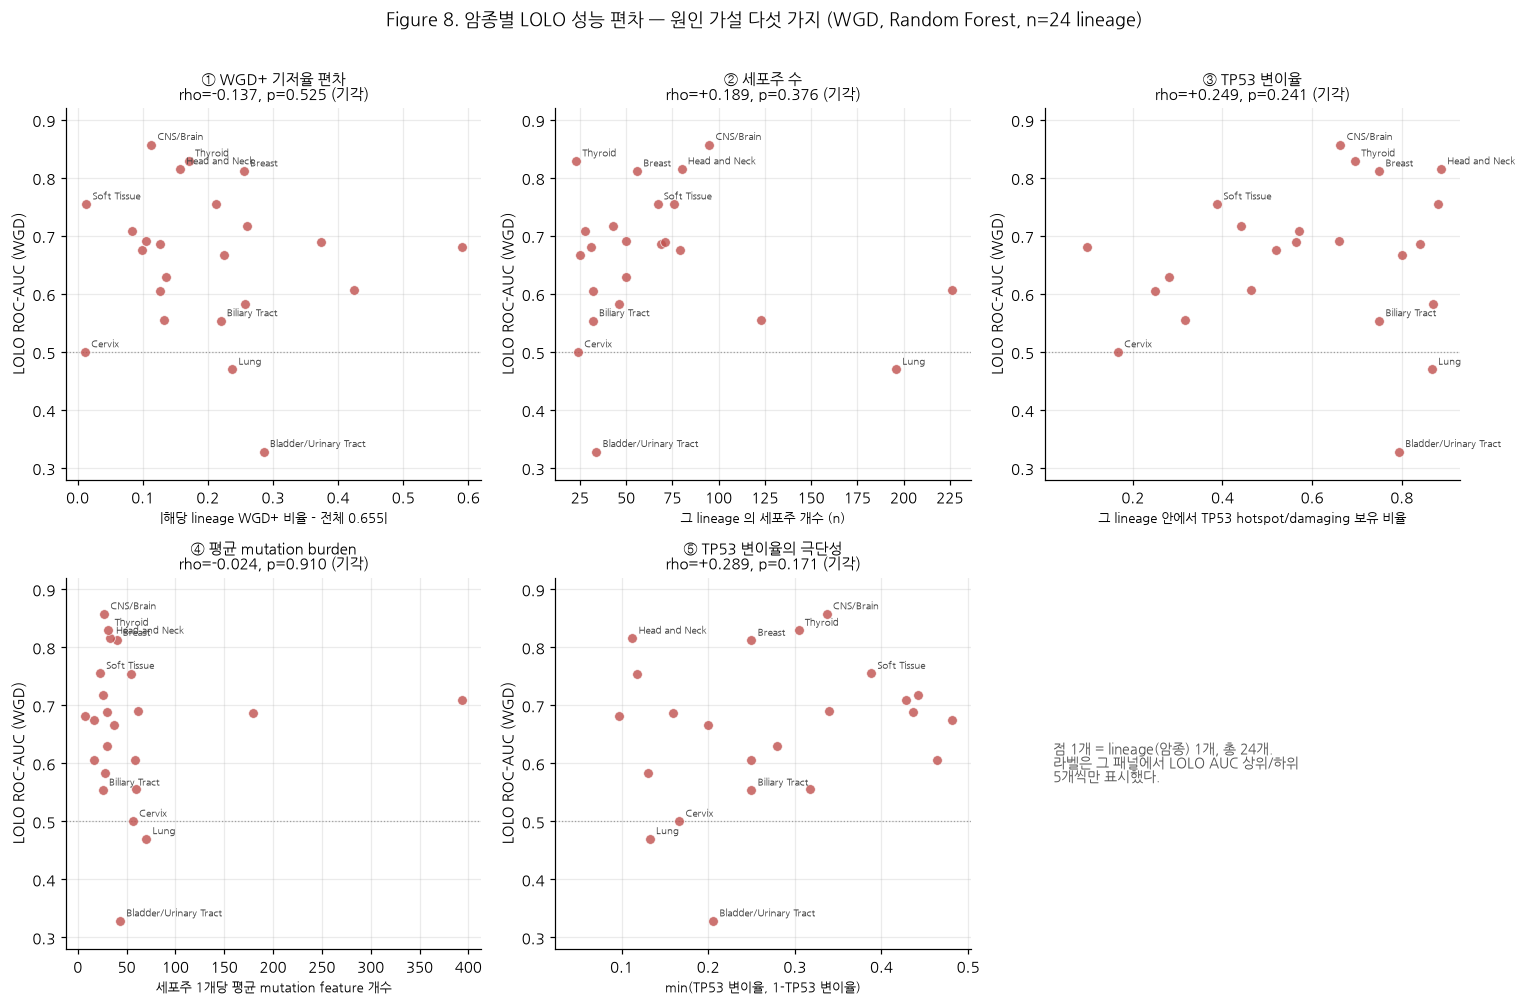

  ① WGD+ 기저율 편차          rho=-0.137 p=0.525
  ② 세포주 수                rho=+0.189 p=0.376
  ③ TP53 변이율             rho=+0.249 p=0.241
  ④ 평균 mutation burden   rho=-0.024 p=0.910
  ⑤ TP53 변이율의 극단성        rho=+0.289 p=0.171


In [15]:
# Figure 8 — scripts/16_plot_lineage_hypotheses.py 를 그대로 옮긴 것 (WGD, Random Forest).
from scipy.stats import spearmanr

TGT = "wgd"
lolo_w = pd.read_csv(TABLES / f"cv_lolo_random_forest_{TGT}.csv")[
    ["held_out_lineage", "roc_auc", "n_test", "positive_rate"]
].rename(columns={"held_out_lineage": "lineage", "n_test": "n"})
global_rate = (lolo_w.positive_rate * lolo_w.n).sum() / lolo_w.n.sum()
lolo_w["base_rate_dev"] = (lolo_w.positive_rate - global_rate).abs()
extra = pd.read_csv(TABLES / f"day15_lineage_hypothesis_features_random_forest_{TGT}.csv")[
    ["lineage", "tp53_rate", "mean_burden", "tp53_extremity"]
]
hyp = lolo_w.merge(extra, on="lineage")


def panel(ax, df, x_col, title, xlabel, n_label=5):
    r = spearmanr(df[x_col], df.roc_auc)
    ax.scatter(df[x_col], df.roc_auc, s=40, color=PHENOTYPE_COLORS[TGT], alpha=0.8,
               edgecolor="white", linewidth=0.5, zorder=3)
    ax.axhline(0.5, color="#999", ls=":", lw=0.8, zorder=1)
    ranked = df.sort_values("roc_auc")
    for _, row in pd.concat([ranked.head(n_label), ranked.tail(n_label)]).drop_duplicates("lineage").iterrows():
        ax.annotate(row.lineage, (row[x_col], row.roc_auc), fontsize=6.5,
                    xytext=(4, 3), textcoords="offset points", color="#444")
    verdict = "기각" if r.pvalue >= 0.05 else "유의"
    ax.set_title(f"{title}\nrho={r.statistic:+.3f}, p={r.pvalue:.3f} ({verdict})", fontsize=9.5)
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.set_ylabel("LOLO ROC-AUC (WGD)")
    ax.set_ylim(0.28, 0.92)


fig, axes = plt.subplots(2, 3, figsize=(14, 9))
specs = [
    ("base_rate_dev", "① WGD+ 기저율 편차", f"|해당 lineage WGD+ 비율 - 전체 {global_rate:.3f}|"),
    ("n", "② 세포주 수", "그 lineage 의 세포주 개수 (n)"),
    ("tp53_rate", "③ TP53 변이율", "그 lineage 안에서 TP53 hotspot/damaging 보유 비율"),
    ("mean_burden", "④ 평균 mutation burden", "세포주 1개당 평균 mutation feature 개수"),
    ("tp53_extremity", "⑤ TP53 변이율의 극단성", "min(TP53 변이율, 1-TP53 변이율)"),
]
for ax, (col, title, xlabel) in zip(axes.flat, specs):
    panel(ax, hyp, col, title, xlabel)
axes.flat[-1].axis("off")
axes.flat[-1].text(0.02, 0.5,
                   "점 1개 = lineage(암종) 1개, 총 24개.\n"
                   "라벨은 그 패널에서 LOLO AUC 상위/하위\n"
                   "5개씩만 표시했다.",
                   fontsize=9, color="#555", va="center", transform=axes.flat[-1].transAxes)

fig.suptitle("Figure 8. 암종별 LOLO 성능 편차 — 원인 가설 다섯 가지 "
             "(WGD, Random Forest, n=24 lineage)", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

for col, title, _ in specs:
    r = spearmanr(hyp[col], hyp.roc_auc)
    print(f"  {title:22s} rho={r.statistic:+.3f} p={r.pvalue:.3f}")

## 8. CIN/LOH 이진화가 정보를 버리는가 — 회귀로 직접 검증

CIN/LoHFraction을 중앙값으로 잘라 분류하는 대신, 같은 mutation feature로 연속값을
직접 회귀 예측해 분류 ROC-AUC와 비교한다.

재현: `python scripts/17_regression_vs_classification.py`.

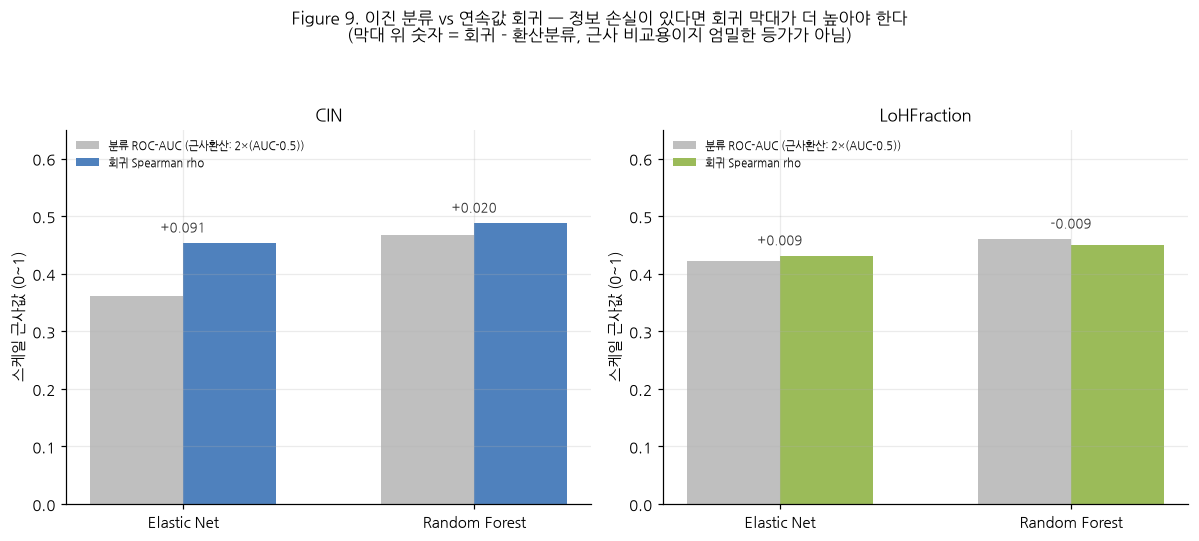

target  model_family  clf_roc_auc  reg_spearman_rho     차이  clf_auc_as_rho
   cin   elastic_net        0.681             0.453  0.091           0.362
   loh   elastic_net        0.711             0.431  0.009           0.422
   cin random_forest        0.734             0.488  0.020           0.468
   loh random_forest        0.730             0.451 -0.009           0.460


In [16]:
# Figure 9 — scripts/18_plot_regression_vs_classification.py 를 그대로 옮긴 것.
cmp_df = pd.read_csv(TABLES / "day15b_regression_vs_classification.csv")
cmp_df["clf_auc_as_rho"] = (cmp_df.clf_roc_auc - 0.5) * 2
families = ["elastic_net", "random_forest"]
family_label = {"elastic_net": "Elastic Net", "random_forest": "Random Forest"}
REG_LABEL = {"cin": "CIN", "loh": "LoHFraction"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, target in zip(axes, ("cin", "loh")):
    sub = cmp_df[cmp_df.target == target].set_index("model_family").reindex(families)
    x, width = np.arange(len(families)), 0.32
    ax.bar(x - width / 2, sub.clf_auc_as_rho, width,
           label="분류 ROC-AUC (근사환산: 2×(AUC-0.5))", color="#bfbfbf")
    ax.bar(x + width / 2, sub.reg_spearman_rho, width,
           label="회귀 Spearman rho", color=PHENOTYPE_COLORS[target])
    for i, (auc_rho, reg_rho) in enumerate(zip(sub.clf_auc_as_rho, sub.reg_spearman_rho)):
        ax.text(i, max(auc_rho, reg_rho) + 0.02, f"{reg_rho - auc_rho:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.set_xticks(x)
    ax.set_xticklabels([family_label[f] for f in families])
    ax.set_ylim(0, 0.65)
    ax.set_ylabel("스케일 근사값 (0~1)")
    ax.set_title(REG_LABEL[target])
    ax.legend(fontsize=7.5, loc="upper left")

fig.suptitle("Figure 9. 이진 분류 vs 연속값 회귀 — 정보 손실이 있다면 회귀 막대가 더 높아야 한다\n"
             "(막대 위 숫자 = 회귀 - 환산분류, 근사 비교용이지 엄밀한 등가가 아님)",
             y=1.06, fontsize=11)
fig.tight_layout()
plt.show()
print(cmp_df.round(3).to_string(index=False))

Random Forest는 CIN·LOH 어느 쪽도 이진화로 정보를 거의 잃지 않는다. **CIN을
Elastic Net(선형 모델)으로 볼 때만** 이진화가 신호를 깎아 먹는다(+0.091). 이
결과의 CIN 패널 재검증은 §11 참고.

## 9. Pathway 단위 재집계 — 실행 결과 (음성)

20,132개 유전자 컬럼을 MSigDB Hallmark 5개 + KEGG DNA repair 6개, 총 11개
gene set으로 재집계했을 때 성능이 어떻게 달라지는지 본다.

재현: `python scripts/19_pathway_representation.py`.

In [17]:
pathway = pd.read_csv(TABLES / "day19_pathway_vs_gene.csv")
pathway

,target,model,gene_level_auc,pathway_auc,차이
0,wgd,logistic,0.723,0.673775,-0.049225
1,cin,logistic,0.672,0.643151,-0.028849
2,loh,logistic,0.683,0.647836,-0.035164
3,wgd,random_forest,0.765,0.720302,-0.044698
4,cin,random_forest,0.734,0.691052,-0.042948
5,loh,random_forest,0.730,0.701923,-0.028077


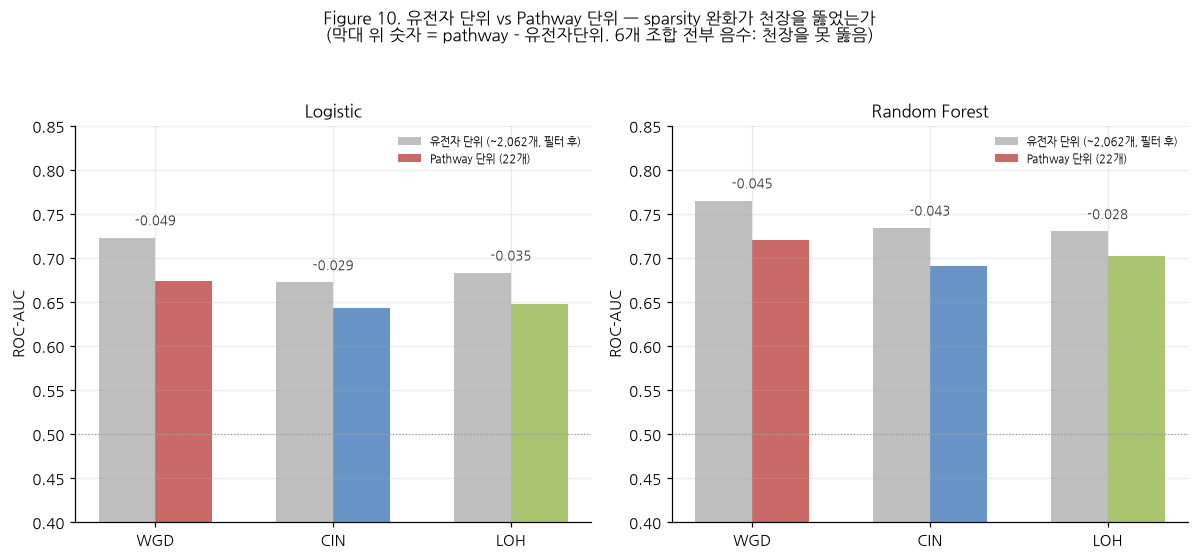

target         model  gene_level_auc  pathway_auc     차이
   wgd      logistic           0.723        0.674 -0.049
   cin      logistic           0.672        0.643 -0.029
   loh      logistic           0.683        0.648 -0.035
   wgd random_forest           0.765        0.720 -0.045
   cin random_forest           0.734        0.691 -0.043
   loh random_forest           0.730        0.702 -0.028


In [18]:
# Figure 10 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day19_pathway_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.pathway_auc, width,
           label="Pathway 단위 (22개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.pathway_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 10. 유전자 단위 vs Pathway 단위 — sparsity 완화가 천장을 뚫었는가\n"
             "(막대 위 숫자 = pathway - 유전자단위. 6개 조합 전부 음수: 천장을 못 뚫음)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

**6개 조합(2모델×3표현형) 전부 pathway 쪽이 낮다(-0.028\~-0.049).** "sparsity를
줄이면 성능이 오른다"는 가설은 기각됐다 — 핵심 신호가 TP53 같은 소수 유전자에
집중돼 있어서, pathway로 뭉뚱그리면 오히려 정보가 희석된다.

## 10. Mutation Signature(96-class) 표현 — 실행 결과 (양성)

DepMap이 별도 배포하는 원시 MAF에서 trinucleotide context를 계산해, COSMIC SBS
표준 96-class 치환 비율을 세포주별 feature로 썼다 — pathway와 정반대로,
**유전자 정체성이 아니라 "어떤 변이 발생 과정이었는가"라는 다른 축의 정보**다.

재현: `python scripts/23_build_mutation_signature.py`,
`python scripts/24_signature_representation.py`.

In [19]:
sig = pd.read_csv(TABLES / "day24_signature_vs_gene.csv")
sig

,target,model,gene_level_auc,signature_auc,차이
0,wgd,logistic,0.723,0.713479,-0.009521
1,cin,logistic,0.672,0.710571,0.038571
2,loh,logistic,0.683,0.693428,0.010428
3,wgd,random_forest,0.765,0.770477,0.005477
4,cin,random_forest,0.734,0.761834,0.027834
5,loh,random_forest,0.730,0.742923,0.012923


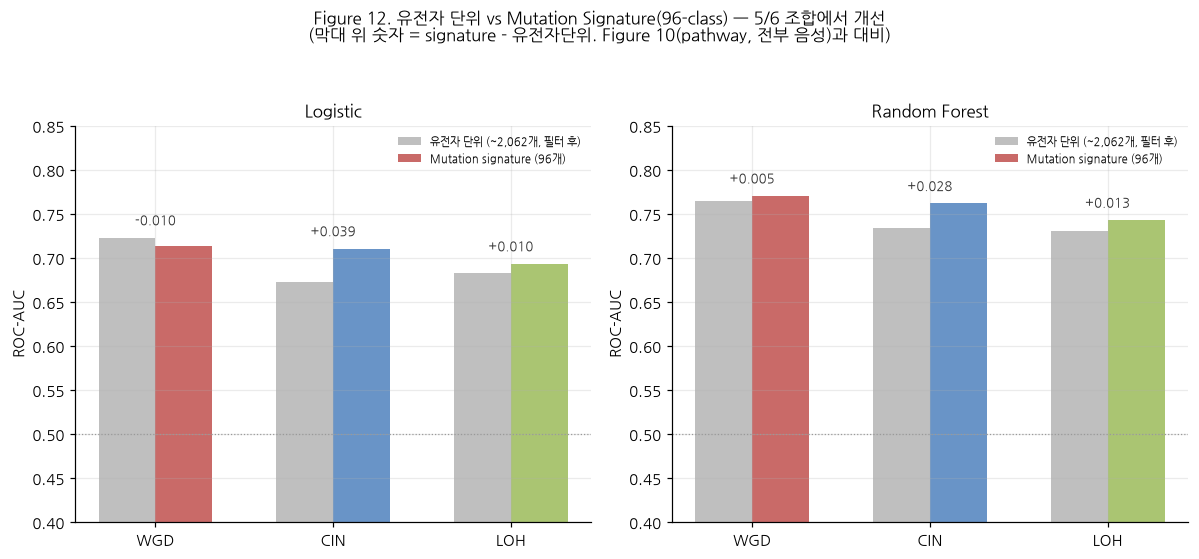

target         model  gene_level_auc  signature_auc     차이
   wgd      logistic           0.723          0.713 -0.010
   cin      logistic           0.672          0.711  0.039
   loh      logistic           0.683          0.693  0.010
   wgd random_forest           0.765          0.770  0.005
   cin random_forest           0.734          0.762  0.028
   loh random_forest           0.730          0.743  0.013


In [20]:
# Figure 12 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day24_signature_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.signature_auc, width,
           label="Mutation signature (96개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.signature_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 12. 유전자 단위 vs Mutation Signature(96-class) — 5/6 조합에서 개선\n"
             "(막대 위 숫자 = signature - 유전자단위. Figure 10(pathway, 전부 음성)과 대비)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

**6개 조합 중 5개가 개선됐다.** 96개라는 훨씬 적은 feature 수로 유전자
\~2,062개 수준의 성능을 냈다. Signature 자체의 최소 패널(20\~30개로 95\~99% 유지)과
3-seed 재현성(변동폭 0.001\~0.005, 매우 안정적) 검증 결과는 아래 Figure
13/15에 있다.

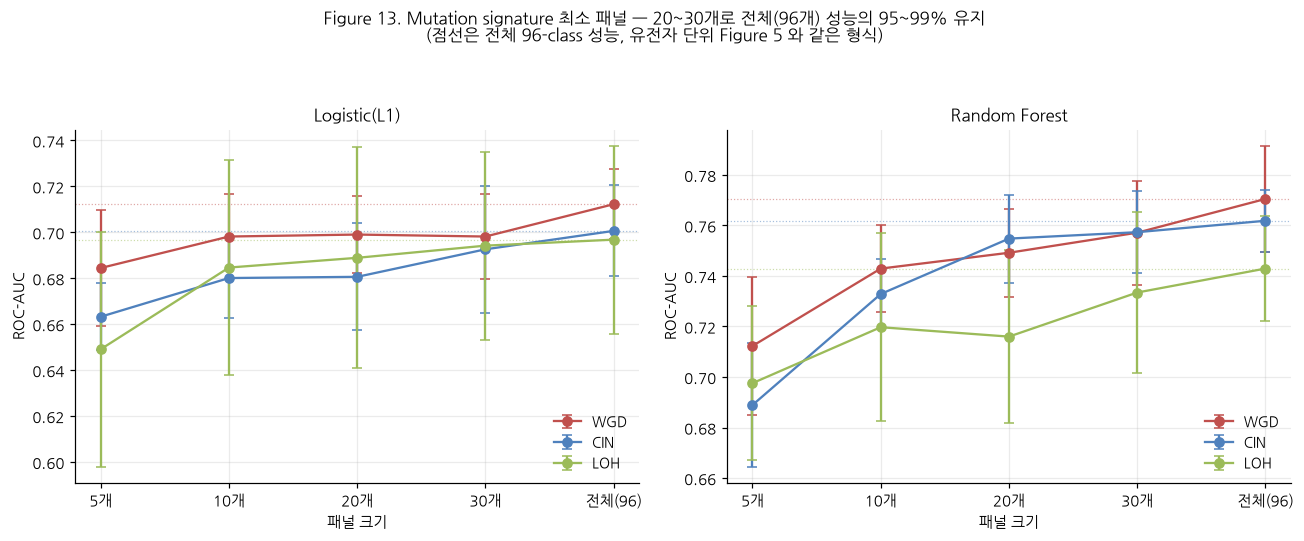

In [21]:
# Figure 13 — scripts/29_plot_signature_panel.py 를 그대로 옮긴 것.
sig_metrics = pd.read_csv(TABLES / "day26_signature_panel_metrics.csv")
SIZES = [5, 10, 20, 30]
order = [str(s) for s in SIZES] + ["all"]
SIG_MODEL_LABEL = {"logistic_l1": "Logistic(L1)", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, model in zip(axes, ("logistic_l1", "random_forest")):
    for target in TARGETS:
        sub = sig_metrics[(sig_metrics.model == model) & (sig_metrics.target == target)]
        g = sub.groupby(sub.panel_size.astype(str)).roc_auc
        mean, std = g.mean().reindex(order), g.std().reindex(order)
        ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                    label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
        full = mean.get("all")
        if pd.notna(full):
            ax.axhline(full, color=PHENOTYPE_COLORS[target], ls=":", lw=0.8, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}개" if o != "all" else "전체(96)" for o in order])
    ax.set_xlabel("패널 크기")
    ax.set_ylabel("ROC-AUC")
    ax.set_title(SIG_MODEL_LABEL[model])
    ax.legend(fontsize=9)

fig.suptitle("Figure 13. Mutation signature 최소 패널 — 20~30개로 전체(96개) 성능의 95~99% 유지\n"
             "(점선은 전체 96-class 성능, 유전자 단위 Figure 5 와 같은 형식)", y=1.06, fontsize=11)
fig.tight_layout()
plt.show()

## 11. 유전자 + Signature 결합 패널

두 축(유전자 정체성 / 변이 발생 과정)을 한 feature 공간에 합쳐서 함께 feature
selection을 시키면 어떻게 될까?

재현: `python scripts/32_combined_gene_signature_panel.py`.

In [22]:
combined = pd.read_csv(TABLES / "day32_combined_vs_single_summary.csv")
combined.round(3)

,model,target,결합,유전자만,signature만,결합-유전자,결합-signature
0,logistic_l1,wgd,0.791,0.723,0.713,0.068,0.078
1,logistic_l1,cin,0.746,0.672,0.711,0.074,0.035
2,logistic_l1,loh,0.755,0.683,0.693,0.072,0.062
3,random_forest,wgd,0.797,0.765,0.770,0.032,0.027
4,random_forest,cin,0.775,0.734,0.762,0.041,0.013
5,random_forest,loh,0.765,0.730,0.743,0.035,0.022


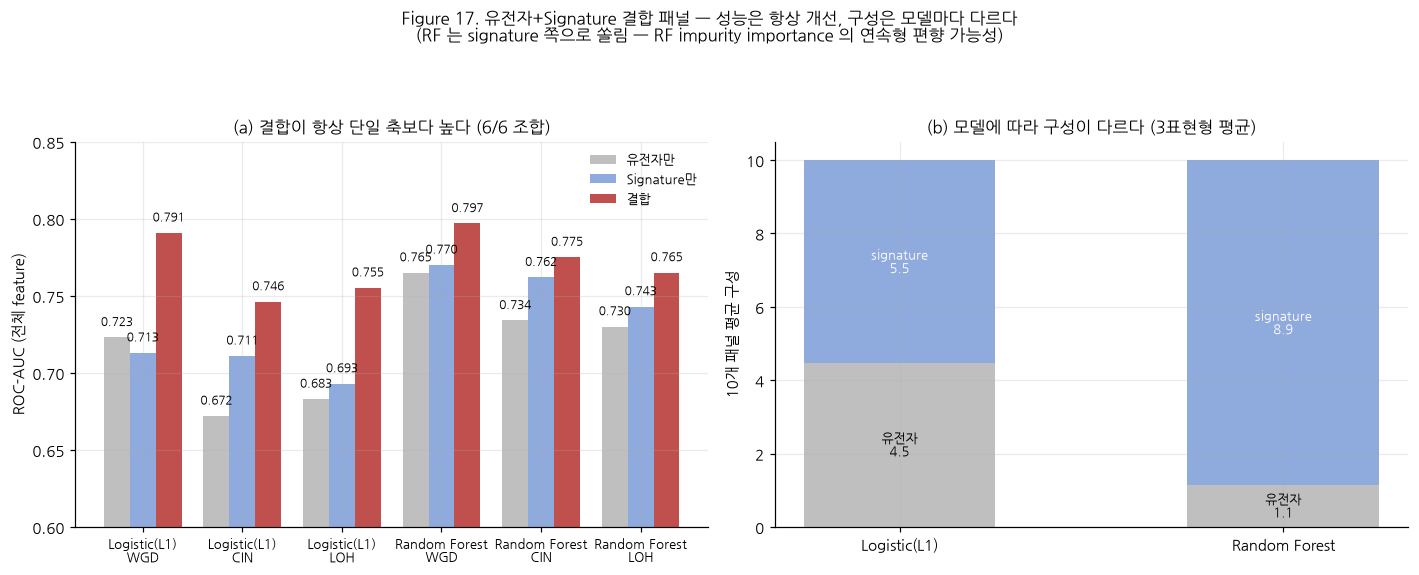

In [23]:
# Figure 17 — scripts/35_plot_combined_panel.py 를 그대로 옮긴 것.
summary = pd.read_csv(TABLES / "day32_combined_vs_single_summary.csv")
comp = pd.read_csv(TABLES / "day32_combined_panel_composition.csv")
CMODELS = ("logistic_l1", "random_forest")
CMODEL_LABEL = {"logistic_l1": "Logistic(L1)", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
combos = [(m, t) for m in CMODELS for t in TARGETS]
x, width = np.arange(len(combos)), 0.26
pick = lambda col: [summary[(summary.model == m) & (summary.target == t)][col].iloc[0]
                    for m, t in combos]
gene_v, sig_v, combined_v = pick("유전자만"), pick("signature만"), pick("결합")

ax.bar(x - width, gene_v, width, label="유전자만", color="#bfbfbf")
ax.bar(x, sig_v, width, label="Signature만", color="#8faadc")
ax.bar(x + width, combined_v, width, label="결합", color="#c0504d")
for i, v in enumerate(gene_v):
    ax.text(i - width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(sig_v):
    ax.text(i, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(combined_v):
    ax.text(i + width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"{CMODEL_LABEL[m]}\n{TARGET_LABEL[t]}" for m, t in combos], fontsize=8.5)
ax.set_ylabel("ROC-AUC (전체 feature)")
ax.set_ylim(0.6, 0.85)
ax.set_title("(a) 결합이 항상 단일 축보다 높다 (6/6 조합)")
ax.legend(fontsize=8.5)

ax2 = axes[1]
comp10 = comp[comp.panel_size == 10].groupby("model")[["n_genes", "n_sig"]].mean().reindex(CMODELS)
xm = np.arange(len(CMODELS))
ax2.bar(xm, comp10.n_genes, 0.5, label="유전자", color="#bfbfbf")
ax2.bar(xm, comp10.n_sig, 0.5, bottom=comp10.n_genes, label="Signature class", color="#8faadc")
for i, (g, s) in enumerate(zip(comp10.n_genes, comp10.n_sig)):
    ax2.text(i, g / 2, f"유전자\n{g:.1f}", ha="center", va="center", fontsize=8.5)
    ax2.text(i, g + s / 2, f"signature\n{s:.1f}", ha="center", va="center", fontsize=8.5, color="white")
ax2.set_xticks(list(xm))
ax2.set_xticklabels([CMODEL_LABEL[m] for m in CMODELS])
ax2.set_ylabel("10개 패널 평균 구성")
ax2.set_title("(b) 모델에 따라 구성이 다르다 (3표현형 평균)")

fig.suptitle("Figure 17. 유전자+Signature 결합 패널 — 성능은 항상 개선, 구성은 모델마다 다르다\n"
             "(RF 는 signature 쪽으로 쏠림 — RF impurity importance 의 연속형 편향 가능성)",
             y=1.08, fontsize=11)
fig.tight_layout()
plt.show()

**6개 조합 전부 결합이 단일 축(유전자만/signature만)보다 높다**
(+0.013\~+0.078). Random Forest+WGD(0.797)는 이 프로젝트 전체에서 가장 높은
ROC-AUC다. 다만 "결합 시 무엇이 선택되는가"는 모델에 따라 다르다 — Random
Forest는 Random Forest importance의 cardinality 편향으로 signature 쪽에 크게
쏠리고(TP53 한 개만 생존), Logistic(L1)은 균형 잡힌 구성을 보이며 기존 핵심
축(TP53/ID3/BRAF/CREBBP)이 그대로 유지된다.

### CIN 회귀 기반 패널 재검증

이진화 손실이 있었던 CIN/Elastic Net 조합에서, 분류 대신 회귀로 다시 뽑은
패널이 기존 분류 패널과 얼마나 겹치는지 확인한다.

재현: `python scripts/28_cin_regression_panel.py`.

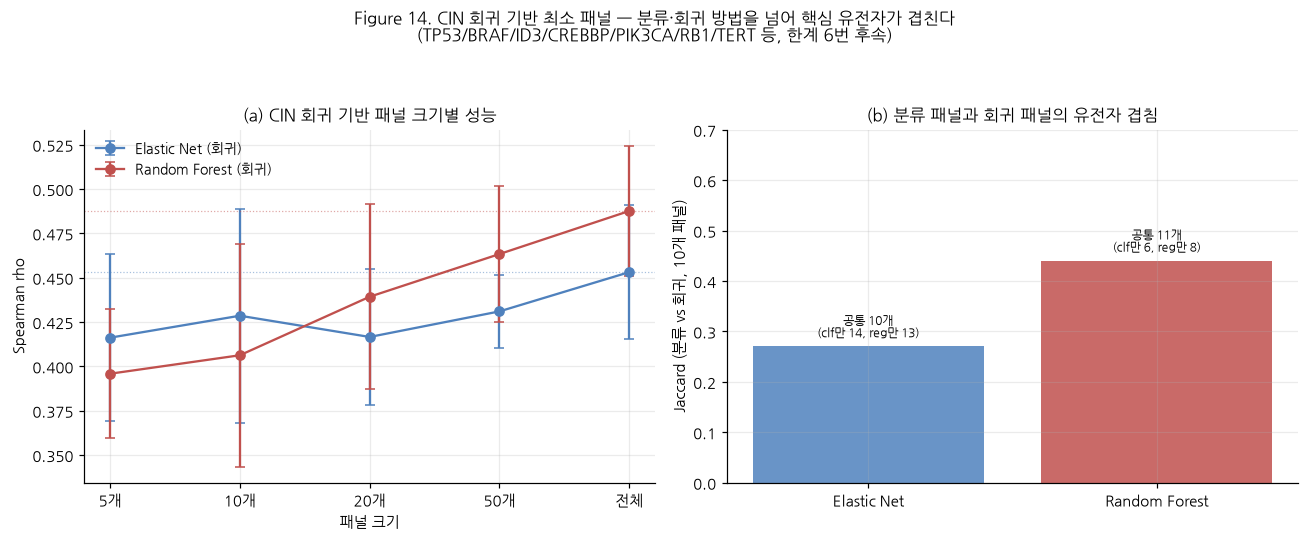

            model  jaccard  n_common  n_clf_only  n_reg_only
  elastic_net_reg     0.27        10          14          13
random_forest_reg     0.44        11           6           8


In [24]:
# Figure 14 — scripts/30_plot_cin_regression_panel.py 를 그대로 옮긴 것.
reg_metrics = pd.read_csv(TABLES / "day28_cin_regression_panel_metrics.csv")
reg_picks = pd.read_csv(TABLES / "day28_cin_regression_panel_picks.csv")
RMODELS = ("elastic_net_reg", "random_forest_reg")
RMODEL_LABEL = {"elastic_net_reg": "Elastic Net (회귀)", "random_forest_reg": "Random Forest (회귀)"}
CLF_MODEL_OF = {"elastic_net_reg": "elastic_net", "random_forest_reg": "random_forest"}
CLF_LABEL = {"elastic_net_reg": "Elastic Net", "random_forest_reg": "Random Forest"}
RSIZES = [5, 10, 20, 50]
RCOLORS = {"elastic_net_reg": "#4f81bd", "random_forest_reg": "#c0504d"}

rows = []
for m in RMODELS:
    clf_picks = pd.read_csv(TABLES / f"day12_panel_picks_{CLF_MODEL_OF[m]}.csv")
    clf_genes = set(clf_picks[(clf_picks.target == "cin") & (clf_picks.panel_size == 10)]
                    .feature.str.split(" \\(").str[0])
    reg_genes = set(reg_picks[(reg_picks.model == m) & (reg_picks.panel_size == 10)]
                    .feature.str.split(" \\(").str[0])
    union = clf_genes | reg_genes
    rows.append({"model": m, "jaccard": len(clf_genes & reg_genes) / len(union) if union else float("nan"),
                 "n_common": len(clf_genes & reg_genes), "n_clf_only": len(clf_genes - reg_genes),
                 "n_reg_only": len(reg_genes - clf_genes)})
overlap = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
order = [str(s) for s in RSIZES] + ["all"]
for m in RMODELS:
    sub = reg_metrics[reg_metrics.model == m]
    g = sub.groupby(sub.panel_size.astype(str)).spearman_rho
    mean, std = g.mean().reindex(order), g.std().reindex(order)
    ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                label=RMODEL_LABEL[m], color=RCOLORS[m])
    full = mean.get("all")
    if pd.notna(full):
        ax.axhline(full, color=RCOLORS[m], ls=":", lw=0.8, alpha=0.5)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"{o}개" if o != "all" else "전체" for o in order])
ax.set_xlabel("패널 크기")
ax.set_ylabel("Spearman rho")
ax.set_title("(a) CIN 회귀 기반 패널 크기별 성능")
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.bar(range(len(RMODELS)), overlap.jaccard, color=[RCOLORS[m] for m in RMODELS], alpha=0.85)
for i, row in overlap.iterrows():
    ax2.text(i, row.jaccard + 0.02, f"공통 {row.n_common}개\n(clf만 {row.n_clf_only},"
             f" reg만 {row.n_reg_only})", ha="center", fontsize=8)
ax2.set_xticks(list(range(len(RMODELS))))
ax2.set_xticklabels([CLF_LABEL[m] for m in RMODELS])
ax2.set_ylabel("Jaccard (분류 vs 회귀, 10개 패널)")
ax2.set_ylim(0, 0.7)
ax2.set_title("(b) 분류 패널과 회귀 패널의 유전자 겹침")

fig.suptitle("Figure 14. CIN 회귀 기반 최소 패널 — 분류·회귀 방법을 넘어 핵심 유전자가 겹친다\n"
             "(TP53/BRAF/ID3/CREBBP/PIK3CA/RB1/TERT 등, 한계 6번 후속)", y=1.06, fontsize=11)
fig.tight_layout()
plt.show()
print(overlap.round(3).to_string(index=False))

분류-회귀 두 방법을 넘어 TP53/BRAF/ID3/CREBBP/PIK3CA/RB1/TERT 핵심 축이 그대로
겹친다(Jaccard 0.27\~0.44) — 이진화 손실이 "어떤 유전자가 선택되는가"에는 크게
반영되지 않았다는 뜻이다.

## 12. Sensitivity/Specificity 트레이드오프

표현 방식(유전자 → signature → 결합)을 바꾸면 sensitivity/specificity 우세가
어떻게 이동하는지 본다.

재현: `python scripts/36_plot_sens_spec_tradeoff.py`.

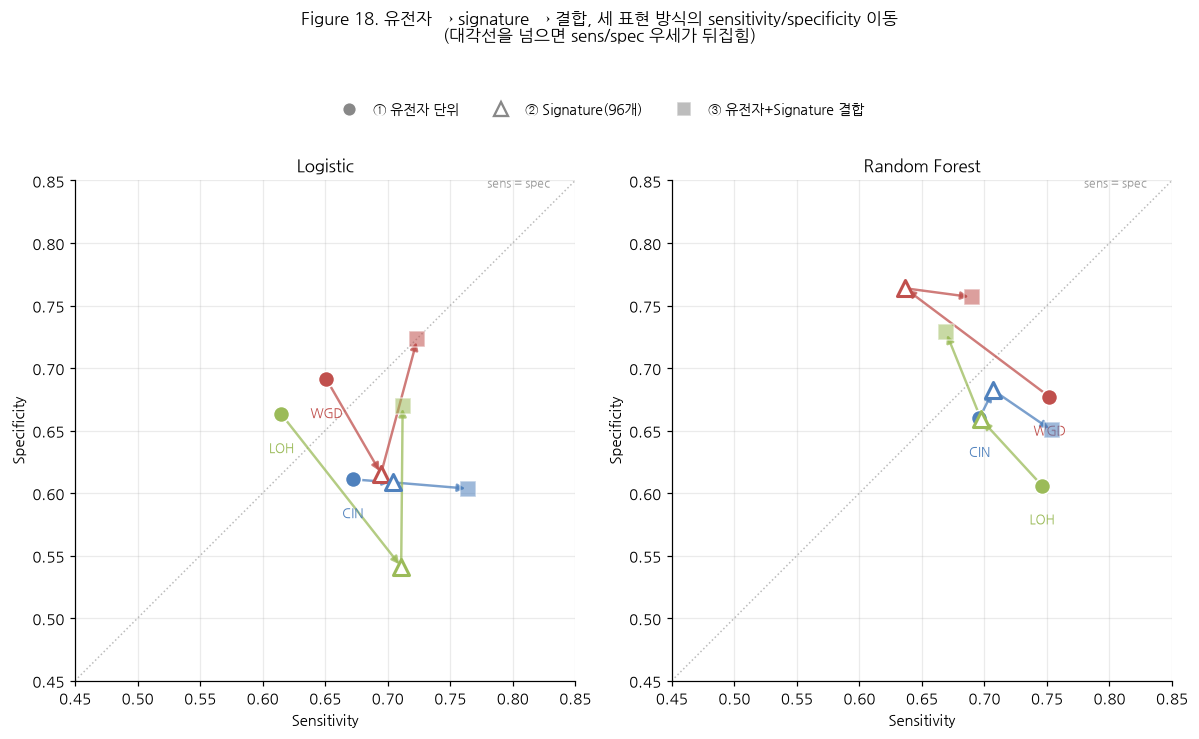

In [25]:
# Figure 18 — scripts/36_plot_sens_spec_tradeoff.py 를 그대로 옮긴 것.
gene = pd.read_csv(TABLES / "day10_model_comparison.csv")
sig = (pd.read_csv(TABLES / "day24_signature_summary.csv")
       .groupby(["target", "model"])[["sensitivity", "specificity"]].mean().reset_index())
comb_raw = pd.read_csv(TABLES / "day32_combined_panel_metrics.csv")
comb = (comb_raw[comb_raw.panel_size.astype(str) == "all"]
        .groupby(["target", "model"])[["sensitivity", "specificity"]].mean().reset_index())
SMODELS = ("logistic", "random_forest")
SMODEL_LABEL = {"logistic": "Logistic", "random_forest": "Random Forest"}
COMBINED_MODEL_OF = {"logistic": "logistic_l1", "random_forest": "random_forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, model in zip(axes, SMODELS):
    ax.plot([0.45, 0.85], [0.45, 0.85], color="#bbb", ls=":", lw=1, zorder=1)
    ax.text(0.83, 0.845, "sens = spec", fontsize=8, color="#999", ha="right")
    for target in TARGETS:
        g = gene[(gene.target == target) & (gene.model == model)].iloc[0]
        s = sig[(sig.target == target) & (sig.model == model)].iloc[0]
        c = comb[(comb.target == target) & (comb.model == COMBINED_MODEL_OF[model])].iloc[0]
        color = PHENOTYPE_COLORS[target]
        points = [(g.sensitivity, g.specificity), (s.sensitivity, s.specificity),
                  (c.sensitivity, c.specificity)]
        for (x0, y0), (x1, y1) in zip(points[:-1], points[1:]):
            ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.6, alpha=0.75), zorder=2)
        ax.scatter(*points[0], marker="o", s=110, color=color, edgecolor="white",
                   linewidth=1, zorder=3)
        ax.scatter(*points[1], marker="^", s=110, facecolor="white", edgecolor=color,
                   linewidth=2, zorder=3)
        ax.scatter(*points[2], marker="s", s=100, color=color, edgecolor="white",
                   linewidth=1, alpha=0.55, zorder=3)
        ax.text(points[0][0], points[0][1] - 0.022, TARGET_LABEL[target],
                fontsize=8.5, color=color, ha="center", va="top")
    ax.set_xlim(0.45, 0.85)
    ax.set_ylim(0.45, 0.85)
    ax.set_xlabel("Sensitivity")
    ax.set_ylabel("Specificity")
    ax.set_title(SMODEL_LABEL[model])
    ax.set_aspect("equal")

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#888", markersize=9, label="① 유전자 단위"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="white", markeredgecolor="#888",
               markeredgewidth=1.5, markersize=9, label="② Signature(96개)"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#888", markersize=9,
               alpha=0.55, label="③ 유전자+Signature 결합"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Figure 18. 유전자 → signature → 결합, 세 표현 방식의 sensitivity/specificity 이동\n"
             "(대각선을 넘으면 sens/spec 우세가 뒤집힘)", y=1.16, fontsize=11)
fig.tight_layout()
plt.show()

CIN은 두 모델 모두 세 단계 내내 sensitivity 우세를 유지하는 반면, WGD와 LOH는
표현 방식을 바꿀 때 대각선(sens=spec)을 넘어가는 지점이 있다 — 표현형에 따라
"표현 방식 선택"이 예측 오류의 방향 자체를 바꿀 수 있다는 뜻이다.

## 13. TCGA 외부 코호트 검증

DepMap 세포주가 아니라 실제 환자 종양 조직(TCGA)에서 WGD를 외부 검증한다.
DepMap 전체로 학습한 모델을 그대로 TCGA에 적용했다(damaging feature만,
hotspot 대응 데이터 없음).

재현: `python scripts/21_tcga_validation.py`.

In [26]:
tcga = pd.read_csv(TABLES / "day21_tcga_validation_summary.csv")
tcga

,stage,roc_auc,n
0,"DepMap 내부(damaging-only, random 5-fold)",0.762229,1631
1,TCGA 외부 검증,0.594063,10261


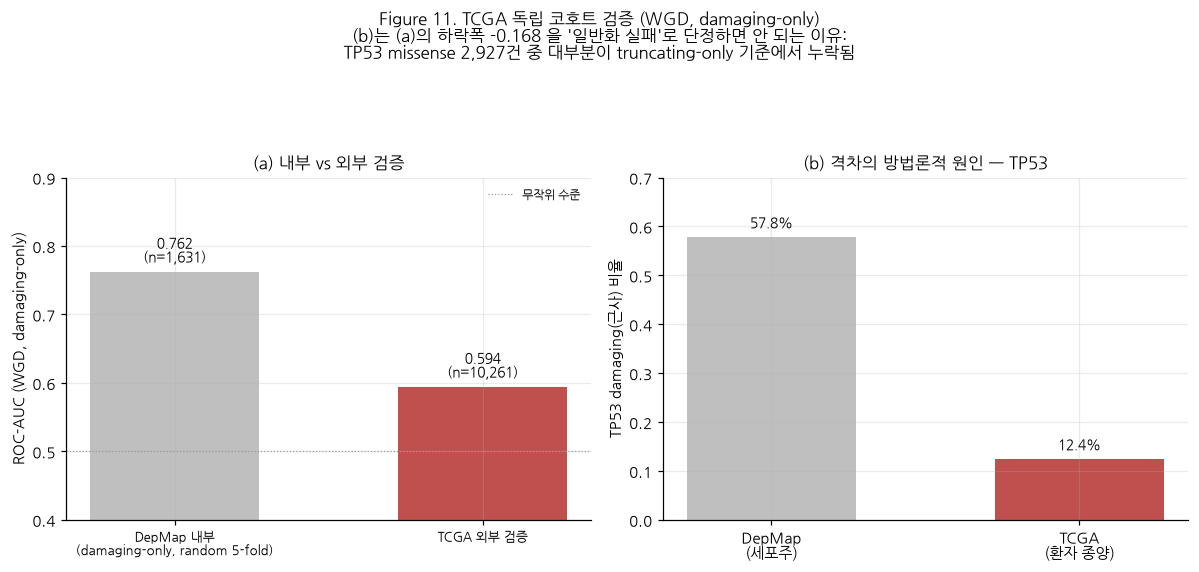

                                  stage  roc_auc     n
DepMap 내부(damaging-only, random 5-fold) 0.762229  1631
                             TCGA 외부 검증 0.594063 10261


In [27]:
# Figure 11 — scripts/22_plot_tcga_validation.py 를 그대로 옮긴 것.
tcga = pd.read_csv(TABLES / "day21_tcga_validation_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
bars = ax.bar(tcga.stage.str.replace("(", "\n(", regex=False), tcga.roc_auc,
              color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for b, v, n in zip(bars, tcga.roc_auc, tcga.n):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}\n(n={n:,})",
            ha="center", fontsize=9)
ax.axhline(0.5, color="#999", ls=":", lw=0.8, label="무작위 수준")
ax.set_ylim(0.4, 0.9)
ax.set_ylabel("ROC-AUC (WGD, damaging-only)")
ax.set_title("(a) 내부 vs 외부 검증")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelsize=8.5)

ax = axes[1]
tp53 = pd.DataFrame({"cohort": ["DepMap\n(세포주)", "TCGA\n(환자 종양)"], "rate": [0.578, 0.124]})
ax.bar(tp53.cohort, tp53.rate, color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for i, v in enumerate(tp53.rate):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylim(0, 0.7)
ax.set_ylabel("TP53 damaging(근사) 비율")
ax.set_title("(b) 격차의 방법론적 원인 — TP53")

fig.suptitle("Figure 11. TCGA 독립 코호트 검증 (WGD, damaging-only)\n"
             "(b)는 (a)의 하락폭 -0.168 을 '일반화 실패'로 단정하면 안 되는 이유:\n"
             "TP53 missense 2,927건 중 대부분이 truncating-only 기준에서 누락됨",
             y=1.12, fontsize=11)
fig.tight_layout()
plt.show()
print(tcga.to_string(index=False))

내부(0.762) 대비 외부(0.594)로 크게 떨어지지만, TCGA의 TP53 damaging 근사
비율이 DepMap보다 훨씬 낮다(57.8% vs 12.4%) — TP53의 주된 불활성화 경로인
missense 변이를 truncating-only 근사가 놓치기 때문으로, **0.594는 실제
일반화 성능의 하한 추정치**에 가깝다.

## 14. 최종 후보 Biomarker Panel

지금까지의 모든 근거(fold 반복선택, 모델 간 합의, 회귀 재검증, TCGA 방향성
지지)를 종합한 최종 후보 8개 유전자다. 상세 근거표는
`docs/research/2026-08-19/biomarker_panel.md` 참고.

In [28]:
core_genes = ["TP53 (damaging+hotspot)", "ID3", "BRAF (hotspot)", "CREBBP"]
phenotype_specific = {
    "WGD": "TERT (hotspot)",
    "CIN": "RB1, PIK3CA (hotspot)",
    "LOH": "PITX1",
}
print("핵심 축 (3표현형 공통):", ", ".join(core_genes))
print()
for target, genes in phenotype_specific.items():
    print(f"  {target} 특이: {genes}")

핵심 축 (3표현형 공통): TP53 (damaging+hotspot), ID3, BRAF (hotspot), CREBBP

  WGD 특이: TERT (hotspot)
  CIN 특이: RB1, PIK3CA (hotspot)
  LOH 특이: PITX1


## 15. 결론 및 한계

- DNA mutation만으로 WGD/CIN/LOH를 ROC-AUC 0.73\~0.77 수준까지 예측 가능하다
  (acceptable 구간이나, 유병률 대비 이득·확률 보정은 제한적).
- Random Forest가 최고 성능이며, 핵심 신호는 TP53을 중심으로 소수 유전자에
  집중돼 있다.
- lineage(암종)를 분리하면 성능이 크게 떨어지고, 그 편차의 원인은 규명하지
  못했다.
- Pathway 재집계는 음성, mutation signature 표현은 양성 — "유전자 정체성"과
  "변이 발생 과정"은 서로 다른, 상보적인 정보다.
- TCGA 외부 검증은 방향은 유지되나 방법론적 한계로 하한 추정치에 그친다.
- 이 결과는 **candidate minimal mutation biomarker panel**이지 임상 확정
  바이오마커가 아니다.

전체 서술형 문서:
- `docs/research/2026-08-16/final_conclusion.md` (Day 1\~13 핵심 결론)
- `docs/research/2026-08-19/additional_results.md` (후속 실험 상세)
- `docs/research/2026-08-19/biomarker_panel.md` (최종 후보 패널 근거)
- `docs/research/2026-08-19/model.md` (모델 비교 상세)